# STAT53894 - Exploratory Data Analysis (EDA)
## Assignment 1
**Student Name:** Afolabi Adesina 
**Class Number:** STAT53894  
**Date:** January 28, 2026

# Table of Contents
1. [Part 1: Dataset Selection and Data Types](#part-1)
2. [Part 2: Summary Statistics](#part-2)
3. [Part 3: Categorical Frequency Counts](#part-3)
4. [Part 4: Numerical Visualizations (Histograms & Boxplots)](#part-4)
5. [Part 5: Categorical Visualizations (Bar Charts)](#part-5)
6. [Part 6: Percentiles and Comparisons](#part-6)

### Setup
I will start by importing the necessary libraries and loading the selected dataset.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Loading the Titanic dataset


In [2]:
titanic = sns.load_dataset('titanic')

## Part 1: Dataset Selection and Identify Data Types

**Selected Dataset:** Titanic dataset (from Seaborn).

In [3]:
# Display the data types
print(titanic.info())
display(titanic.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Questions:
**1. How many categorical variables are in the dataset?**
Based on the data types, there are **8** categorical variables in the Titanic dataset (`sex`, `embarked`, `class`, `who`, `adult_male`, `deck`, `embark_town`, `alive`). Note that `pclass` is encoded as integers but represent categories (Ordinal data) to classify the class and also `alone` which is binary can also be classified as categorical variable. Overall there are **10** Categorical Variable in the dataset


**2. Give two examples of numerical variables and explain why they are numerical.**
*   **Age:** This is a numerical (continuous) variable because it represents a measured value on an interval scale.
*   **Fare:** This is a numerical (continuous) variable because it represents the monetary cost paid, which can take any positive float value.


## Part 2: Summary Statistics
### Tasks:
I have selected `age` and `fare` as my two numerical variables.

In [4]:
# Compute statistics for Age and Fare
numerical_vars = ['age', 'fare']
summary_stats = titanic[numerical_vars].describe().T
summary_stats['median'] = titanic[numerical_vars].median()
summary_stats['range'] = titanic[numerical_vars].max() - titanic[numerical_vars].min()
summary_stats['IQR'] = summary_stats['75%'] - summary_stats['25%']
print(summary_stats[['mean', 'median', '25%', '75%', 'range', 'IQR']])

           mean   median      25%   75%     range      IQR
age   29.699118  28.0000  20.1250  38.0   79.5800  17.8750
fare  32.204208  14.4542   7.9104  31.0  512.3292  23.0896


### Questions:
**1. What does the median tell you about the typical value?**
The median represents the 50th percentile (the middle value). Unlike the mean, it is a **robust** measure, meaning it represents the "typical" value without being pulled upward or downward by extreme outliers like very high ticket fares.

**2. How does the IQR help describe the spread of the data?**
The Interquartile Range (IQR) measures the spread of the middle 50% of the data. It is the difference between the 75th and 25th percentiles. A larger IQR indicates that the bulk of the data is more spread out from the center.

## Part 3: Frequency Counts for Categorical Variables

I have selected `sex` and `class` as my two categorical variables.

In [5]:
# Value counts and percentages for 'class'
class_counts = titanic['class'].value_counts()
class_percent = titanic['class'].value_counts(normalize=True) * 100

print("Frequency of Passenger Class:\n", class_counts)
print("\nPercentage of Passenger Class:\n", class_percent)

Frequency of Passenger Class:
 class
Third     491
First     216
Second    184
Name: count, dtype: int64

Percentage of Passenger Class:
 class
Third     55.106622
First     24.242424
Second    20.650954
Name: proportion, dtype: float64


## Part 4: Histograms and Boxplots

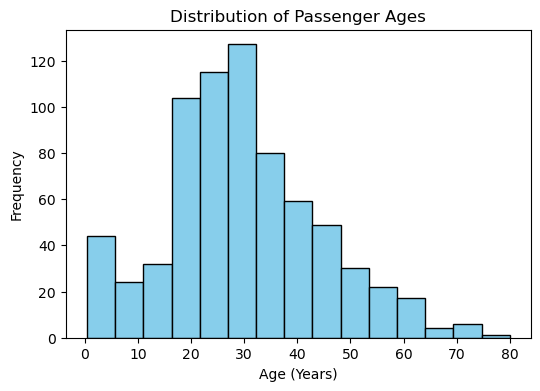

In [6]:
# Histogram for Age
plt.figure(figsize=(6, 4))
titanic['age'].plot.hist(
    bins=15, 
    color='skyblue', 
    edgecolor='black', 
    title='Distribution of Passenger Ages'
)
plt.xlabel('Age (Years)')
plt.ylabel('Frequency')
plt.show()


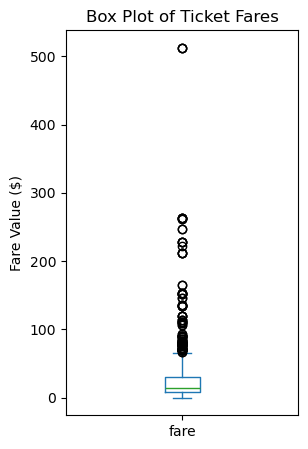

In [7]:
# Boxplot for Fare
plt.figure(figsize=(3, 5)) 
ax = titanic['fare'].plot.box(title='Box Plot of Ticket Fares')
ax.set_ylabel('Fare Value ($)') # Labeling the Y-axis for vertical orientation
plt.show()

### Questions:
**1. Describe the shape of each distribution (symmetric, skewed).**
*   **Age:** The distribution is relatively symmetric but slightly **right-skewed**, with a higher concentration of young adults.
*   **Fare:** The distribution is **highly right-skewed**, meaning most passengers paid low fares, while a few paid extremely high amounts.

**2. Are there any outliers? How can you tell?**
Yes, there are significant outliers in the `fare` variable. We can tell because the boxplot shows many individual points beyond the upper "whisker", which represents values far exceeding the $Q3 + 1.5 \times IQR$ fence.

## Part 5: Bar Charts for Categorical Variables


### Tasks:
I will create a bar chart for `embark_town` and use `survived` as the hue.

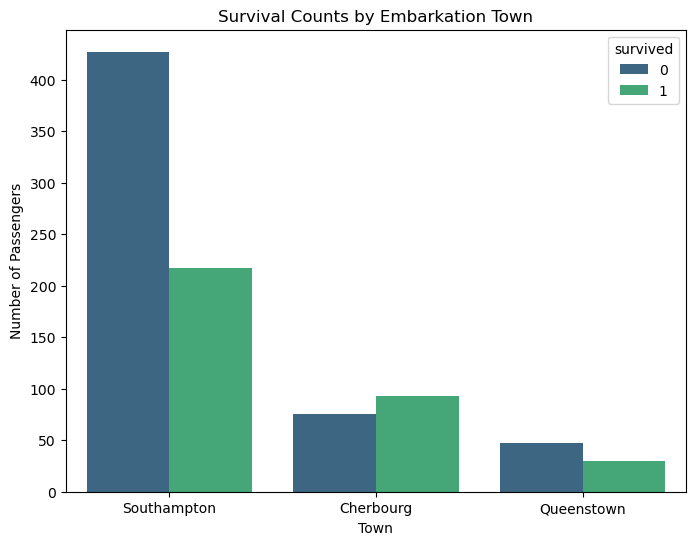

In [8]:
plt.figure(figsize=(8, 6))
sns.countplot(data=titanic, x='embark_town', hue='survived', palette='viridis')
plt.title('Survival Counts by Embarkation Town')
plt.xlabel('Town')
plt.ylabel('Number of Passengers')
plt.show()

### Questions:
**1. Which category has the highest count?**
**Southampton** is the category with the highest count, as it was the primary departure point for the majority of the passengers.

**2. What differences do you observe across groups?**
Passengers embarking from Cherbourg had a higher proportion of survivors compared to non-survivors, whereas in Southampton, significantly more people died than survived. This suggests a relationship between boarding area (most likely linked to passenger class) and survival chance.

## Part 6: Percentiles and Comparisons

### Tasks:
I will analyze the `fare` variable to identify the top 10% of spenders.

In [9]:
# Compute specific percentiles
percentiles = [10, 25, 50, 75, 90]
fare_values = np.percentile(titanic['fare'], percentiles)

for p, val in zip(percentiles, fare_values):
    print(f"{p}th Percentile of Fare: ${val:.2f}")

10th Percentile of Fare: $7.55
25th Percentile of Fare: $7.91
50th Percentile of Fare: $14.45
75th Percentile of Fare: $31.00
90th Percentile of Fare: $77.96


In [10]:
# Identify observations in the top 10%
top_10_threshold = fare_values[-1] # 90th percentile
top_10_passengers = titanic[titanic['fare'] > top_10_threshold]
display(top_10_passengers)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False
31,1,1,female,NaN,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,NaN,Cherbourg,no,False
61,1,1,female,38.0,0,0,80.0000,NaN,First,woman,False,B,NaN,yes,True
62,0,1,male,45.0,1,0,83.4750,S,First,man,True,C,Southampton,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829,1,1,female,62.0,0,0,80.0000,NaN,First,woman,False,B,NaN,yes,True
835,1,1,female,39.0,1,1,83.1583,C,First,woman,False,E,Cherbourg,yes,False
849,1,1,female,NaN,1,0,89.1042,C,First,woman,False,C,Cherbourg,yes,False
856,1,1,female,45.0,1,1,164.8667,S,First,woman,False,NaN,Southampton,yes,False


### Questions:
**1. What does the 10th percentile tell you?**
The 10th percentile tells us that 10% of all passengers paid a fare of **$7.55 or less**. It identifies the lowest-spending group in the dataset.

**2. How would you describe the observations in the top 10%?**
The observations in the top 10% represent the elite passengers who paid more than **$77.96**. This group is likely composed almost entirely of First Class passengers and contains the "outliers" identified in the earlier boxplot.


### References 

**Loading Datasets (Seaborn)**
The command `sns.load_dataset('titanic')` used to retrieve the data. 

*Source:* [Seaborn Documentation - load_dataset](https://seaborn.pydata.org/generated/seaborn.load_dataset.html)

**Computing Percentiles (NumPy)**
 np.percentile() was used to find the 10th and 90th percentiles. 

*Source:* [NumPy Documentation - numpy.percentile](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html)

**Plotting Techniques from STAT50002: Data Visualization Class**
